### Data pre-processing

In [50]:
import torch
import torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset,DataLoader
torch.manual_seed(50)
generator=torch.Generator()
generator.manual_seed(50)
data=load_iris()
x=torch.tensor(data.data,dtype=torch.float32)
y=torch.tensor(data.target,dtype=torch.long)
train_x,temp_x,train_y,temp_y=train_test_split(x,y,test_size=0.3,random_state=50)
val_x,test_x,val_y,test_y=train_test_split(temp_x,temp_y,test_size=0.5,random_state=50)
print(train_x.shape)
print(train_y.shape)
dataset=TensorDataset(train_x,train_y)
loader=DataLoader(dataset,batch_size=10,shuffle=True,generator=generator)

torch.Size([105, 4])
torch.Size([105])


### Model

In [35]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1=nn.Linear(4,20)
        self.layer2=nn.Linear(20,3)
    def forward(self,x):
        x=self.layer1(x)
        x=torch.sigmoid(x)
        x=self.layer2(x)
        return x

### Training, Validation and Testing

In [56]:
epoch=500
loss_fn=nn.CrossEntropyLoss()
model=ANN()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)
for i in range(epoch):
    total_loss=0
    for batch_x,actual in loader:
        predicted=model.forward(batch_x)
        loss=loss_fn(predicted,actual)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss+=loss.item()

    model.eval()
    with torch.no_grad():
        predicted=model(val_x)
        val_loss=loss_fn(predicted,val_y)
    if i%40==0:
        print(f"training loss: {total_loss} validation loss: {val_loss}")
model.eval()
with torch.no_grad():
    predicted = model(test_x)
    loss=loss_fn(predicted,test_y)
    print(f"loss during testing : {loss.item()}")
    predicted_class = torch.argmax(predicted, dim=1)

training loss: 13.075815916061401 validation loss: 1.1689867973327637
training loss: 8.967845022678375 validation loss: 0.7910876870155334
training loss: 6.443662017583847 validation loss: 0.5800792574882507
training loss: 5.3509860932827 validation loss: 0.48225143551826477
training loss: 4.751510709524155 validation loss: 0.42612457275390625
training loss: 4.3293847888708115 validation loss: 0.3847000002861023
training loss: 3.909482330083847 validation loss: 0.349217027425766
training loss: 3.4725315123796463 validation loss: 0.31740906834602356
training loss: 3.1684569269418716 validation loss: 0.2892419397830963
training loss: 2.8831761479377747 validation loss: 0.26357337832450867
training loss: 2.6801315248012543 validation loss: 0.24098601937294006
training loss: 2.444028988480568 validation loss: 0.222626730799675
training loss: 2.2084145098924637 validation loss: 0.20692051947116852
loss during testing : 0.21258088946342468


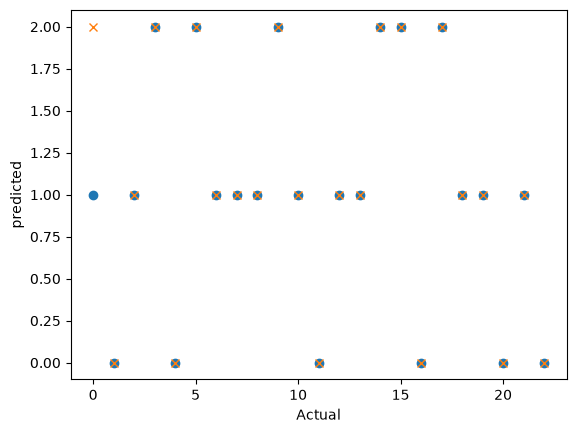

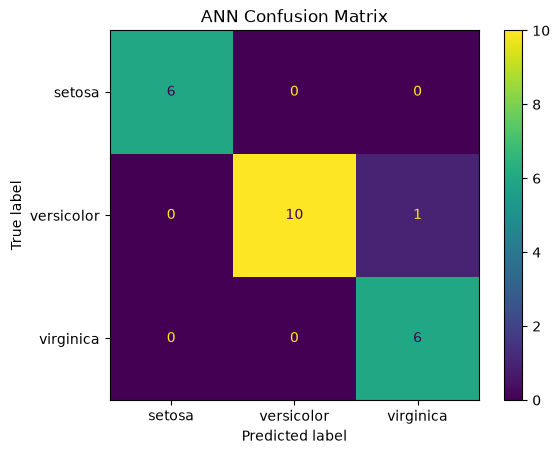

In [62]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
plt.figure()
plt.plot(test_y.numpy(),"o",label="actual")
plt.plot(predicted_class.numpy(),"x",label="predicted")
plt.xlabel("Actual")
plt.ylabel("predicted")
plt.show()

cm = confusion_matrix(test_y.numpy(),predicted_class.numpy())
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=data.target_names)
disp.plot()
plt.title("ANN Confusion Matrix")
plt.show()